# NYC PLUTO - Choosing the Number of Clusters (k)

**Course:** Data Engineering - Unsupervised Learning Project
**University:** Bar-Ilan University, Spring 2026
**Author:** Elie Hamou

**Why this notebook.** Our pipeline consistently selects **k=2**, chosen on the
silhouette score. This raised a fair objection: the silhouette *mechanically* favours
small k, so it cannot, on its own, prove that 2 is the right number; and the choice
should be re-tested **after PCA**. This notebook is an **independent** re-examination -
it does *not* reuse the clustering notebook's code. It rebuilds the evaluation from
scratch on `X_scaled.csv` and asks one question:

> Is **k=2** the best choice for PLUTO, mathematically and statistically -
> and does the answer change in PCA space?

**Method.** Eight criteria, computed in **both** the full 16D standardized space and the
PCA (90% variance) space:
elbow (inertia), silhouette, Calinski-Harabasz, Davies-Bouldin, the **gap statistic**
(Tibshirani), **GMM BIC/AIC**, partition **stability** (ARI across seeds), and a Ward
**dendrogram**. We then confront the metrics with a question raised by the 2D plot:
*"it looks like there are 3 clusters, not 2."*

**Outline**
1. Setup
2. How many clusters? - multi-criterion evidence
3. "But the 2D PCA plot looks like 3" - clustering k=2..6 in PCA space
4. Verdict

## 1. Setup

In [1]:
from pathlib import Path
import warnings, time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, calinski_harabasz_score,
                             davies_bouldin_score, adjusted_rand_score)
from scipy.cluster.hierarchy import linkage, dendrogram

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
RANDOM_STATE = 42

# Robust project-root detection (same pattern as the other notebooks).
search_dir = Path.cwd().resolve()
for candidate in [search_dir, *search_dir.parents]:
    if (candidate / "data" / "processed").is_dir() and (candidate / "requirements.txt").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate project root.")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

X_full = pd.read_csv(PROCESSED_DIR / "X_scaled.csv").values
companion = pd.read_csv(PROCESSED_DIR / "pluto_companion.csv", index_col=0)
print("X_scaled:", X_full.shape)

# PCA space retaining 90% of the variance, plus the first 2 PCs for plotting.
pca = PCA(random_state=RANDOM_STATE).fit(X_full)
evr = pca.explained_variance_ratio_
K90 = int(np.searchsorted(np.cumsum(evr), 0.90)) + 1
P_full = pca.transform(X_full)
X_pca = P_full[:, :K90]
print(f"PCA space: {K90} components (90% variance)")

# One fixed 50k sample is reused everywhere so all numbers are comparable.
rng = np.random.RandomState(RANDOM_STATE)
idx = rng.choice(len(X_full), 50_000, replace=False)
Xf, Xp, P2 = X_full[idx], X_pca[idx], P_full[idx, :2]
sil_sub = rng.choice(len(idx), 10_000, replace=False)   # exact-silhouette subsample
rr = companion["residential_ratio"].values[idx]
lu = companion["landuse"].values[idx]
print("Sample:", Xf.shape[0], "rows")

X_scaled: (682515, 16)
PCA space: 10 components (90% variance)
Sample: 50000 rows


## 2. How many clusters? Multi-criterion evidence

A single internal index is not enough. The **silhouette** and **Calinski-Harabasz**
indices tend to reward the *widest* separation, which usually means small k. The
**gap statistic** compares the data to a structure-less uniform reference, and **GMM
BIC/AIC** judge it from a probabilistic model. We run all of them, in both spaces.

### 2.1 K-Means internal indices (k = 2..15), full 16D vs PCA

In [2]:
KS = list(range(2, 16))

def evaluate_space(Xs):
    rows, labels_by_k = [], {}
    for k in KS:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(Xs)
        labels_by_k[k] = km.labels_
        rows.append(dict(
            k=k, inertia=km.inertia_,
            silhouette=silhouette_score(Xs[sil_sub], km.labels_[sil_sub]),
            calinski_harabasz=calinski_harabasz_score(Xs, km.labels_),
            davies_bouldin=davies_bouldin_score(Xs, km.labels_),
        ))
    return pd.DataFrame(rows).set_index("k"), labels_by_k

df_full, _ = evaluate_space(Xf)
df_pca,  _ = evaluate_space(Xp)

for name, df in [("FULL 16D", df_full), (f"PCA {K90}D", df_pca)]:
    print(f"\n--- {name} ---")
    print(df.round(3).to_string())
    print(f"  argmax silhouette -> k={df['silhouette'].idxmax()}   "
          f"argmax CH -> k={df['calinski_harabasz'].idxmax()}   "
          f"argmin DB -> k={df['davies_bouldin'].idxmin()}")


--- FULL 16D ---
       inertia  silhouette  calinski_harabasz  davies_bouldin
k                                                            
2   639731.980       0.463          12578.115           1.718
3   535430.386       0.286          12383.710           1.594
4   488761.253       0.227          10635.219           1.704
5   447146.681       0.238           9881.816           1.534
6   419024.358       0.219           9106.888           1.539
7   392028.963       0.165           8685.286           1.535
8   363280.938       0.231           8598.635           1.456
9   332588.293       0.239           8794.625           1.343
10  314798.502       0.194           8572.973           1.371
11  294772.815       0.202           8579.302           1.298
12  282546.458       0.195           8333.323           1.326
13  270354.947       0.209           8171.031           1.282
14  262158.785       0.204           7898.355           1.300
15  249903.383       0.214           7868.789       

### 2.2 Elbow, gap statistic, GMM BIC/AIC, and stability

In [3]:
# Elbow: maximum curvature (second difference) of the inertia curve.
def elbow_k(df):
    d2 = np.diff(df["inertia"].values, 2)
    return KS[int(np.argmax(d2)) + 1]
print(f"Elbow (max 2nd-diff inertia): full 16D -> k={elbow_k(df_full)}, PCA -> k={elbow_k(df_pca)}")

Elbow (max 2nd-diff inertia): full 16D -> k=3, PCA -> k=3


In [4]:
# Gap statistic (Tibshirani et al., 2001), full 16D, B=10 uniform references.
N_GAP, B = 5000, 10
gi = rng.choice(len(X_full), N_GAP, replace=False)
Xg = X_full[gi]
mins, maxs = Xg.min(0), Xg.max(0)
gap_ks = list(range(1, 11))

def Wk(Xs, k):
    if k == 1:
        return ((Xs - Xs.mean(0, keepdims=True)) ** 2).sum()
    return KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=5).fit(Xs).inertia_

logW = np.array([np.log(Wk(Xg, k)) for k in gap_ks])
ref = np.array([[np.log(Wk(rng.uniform(mins, maxs, Xg.shape), k)) for k in gap_ks]
                for _ in range(B)])
gap = ref.mean(0) - logW
sk = ref.std(0) * np.sqrt(1 + 1.0 / B)
gap_choice = next((gap_ks[i] for i in range(len(gap_ks) - 1)
                   if gap[i] >= gap[i + 1] - sk[i + 1]), gap_ks[-1])
print(pd.DataFrame({"k": gap_ks, "gap": gap.round(4), "s_k": sk.round(4)}).to_string(index=False))
print("Gap-statistic optimal k (Tibshirani rule):", gap_choice)

 k    gap    s_k
 1 1.8611 0.0057
 2 1.7495 0.0056
 3 1.8367 0.0025
 4 1.8429 0.0050
 5 1.8548 0.0046
 6 1.8890 0.0048
 7 1.9201 0.0042
 8 1.9728 0.0044
 9 2.0122 0.0040
10 2.0154 0.0039
Gap-statistic optimal k (Tibshirani rule): 1


In [5]:
# Model-based selection: Gaussian Mixture BIC / AIC (lower is better).
gmi = rng.choice(len(X_full), 20_000, replace=False)
Xgmm = X_full[gmi]
bic, aic = [], []
for k in KS:
    g = GaussianMixture(n_components=k, covariance_type="full",
                        random_state=RANDOM_STATE, n_init=2, max_iter=200).fit(Xgmm)
    bic.append(g.bic(Xgmm)); aic.append(g.aic(Xgmm))
bic, aic = np.array(bic), np.array(aic)
print("GMM BIC-optimal k =", KS[int(np.argmin(bic))], "| AIC-optimal k =", KS[int(np.argmin(aic))])

GMM BIC-optimal k = 15 | AIC-optimal k = 15


In [6]:
# Stability: a real cluster structure should reproduce across random seeds.
# We measure the mean pairwise Adjusted Rand Index over 5 seeds.
print("Mean pairwise ARI across 5 seeds (full 16D):")
stab = {}
for k in [2, 3, 4, 5, 6, 8]:
    labs = [KMeans(n_clusters=k, random_state=s, n_init=10).fit_predict(Xf) for s in range(5)]
    aris = [adjusted_rand_score(labs[i], labs[j]) for i in range(5) for j in range(i + 1, 5)]
    stab[k] = float(np.mean(aris))
    print(f"  k={k}: ARI = {stab[k]:.3f}")

Mean pairwise ARI across 5 seeds (full 16D):


  k=2: ARI = 1.000


  k=3: ARI = 1.000


  k=4: ARI = 0.914


  k=5: ARI = 0.877


  k=6: ARI = 0.898


  k=8: ARI = 0.736


### 2.3 Diagnostic panel

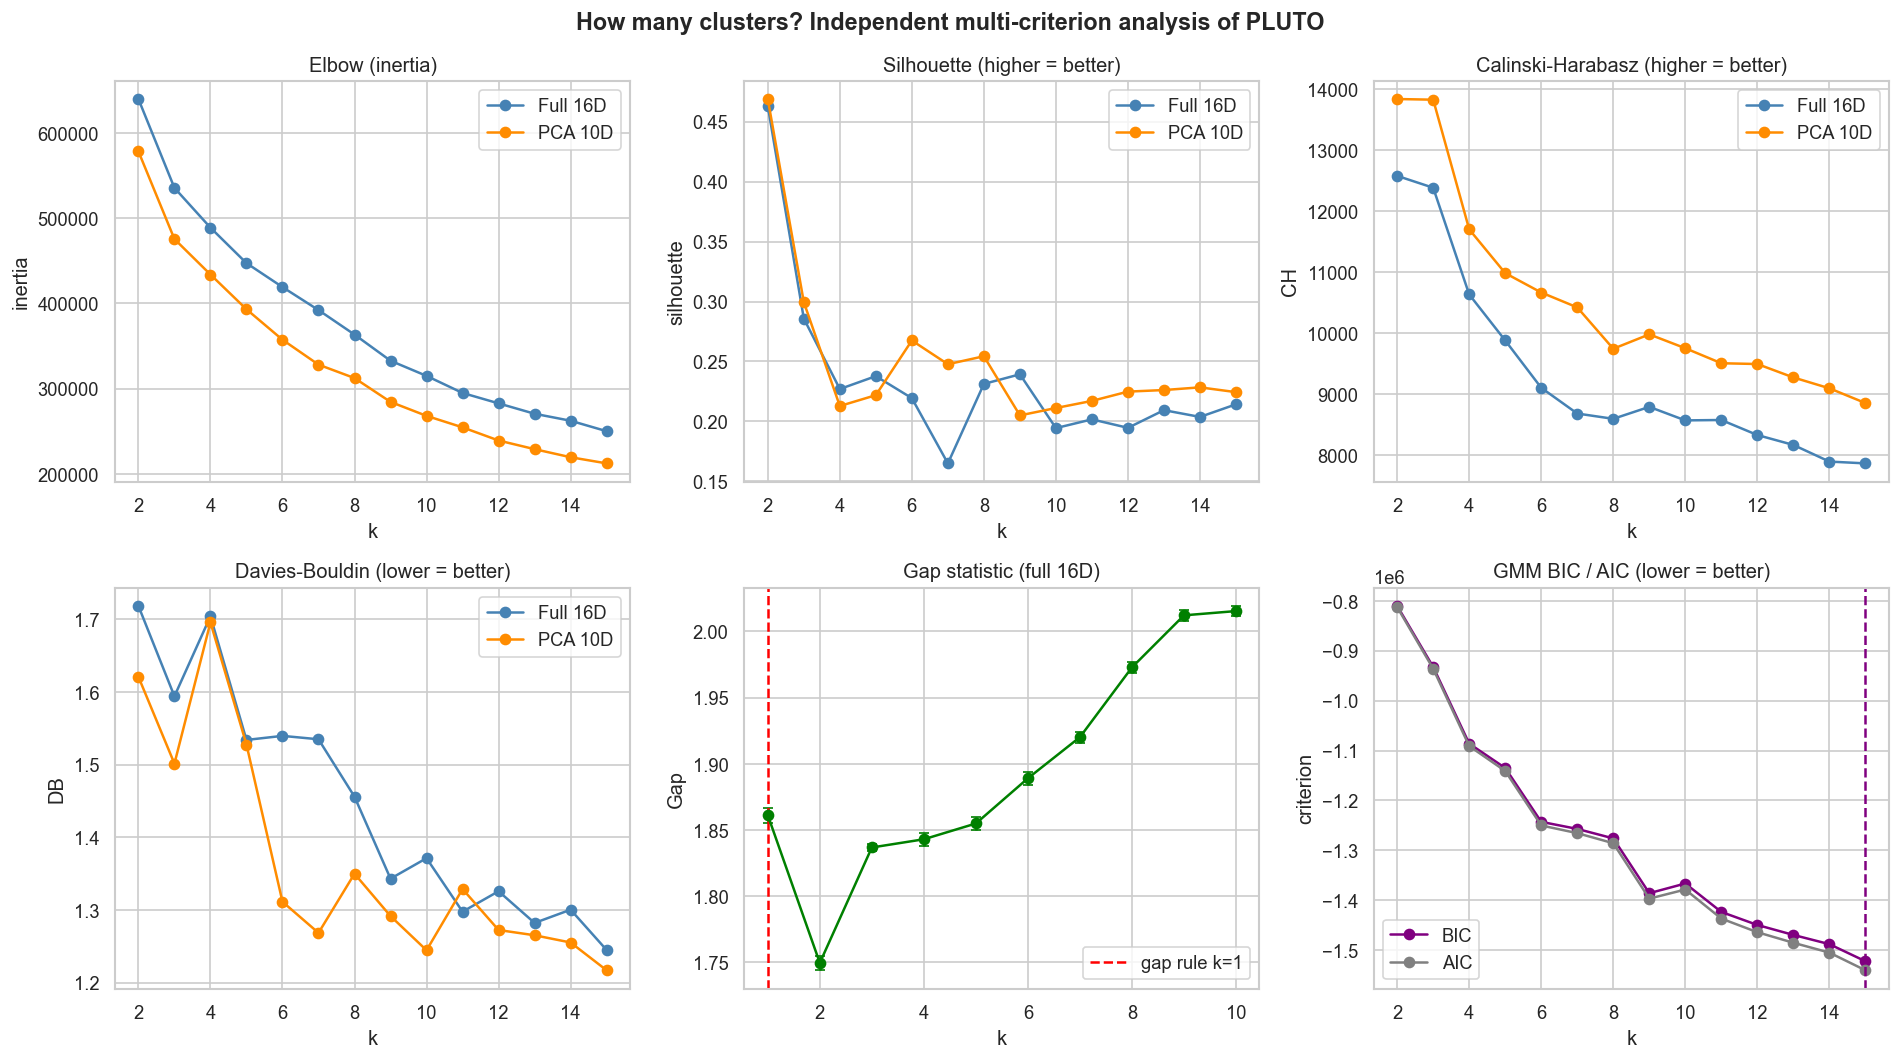

In [7]:
fig, ax = plt.subplots(2, 3, figsize=(16, 9)); ax = ax.ravel()
for df, lab, c in [(df_full, "Full 16D", "steelblue"), (df_pca, f"PCA {K90}D", "darkorange")]:
    ax[0].plot(df.index, df["inertia"], marker="o", label=lab, color=c)
    ax[1].plot(df.index, df["silhouette"], marker="o", label=lab, color=c)
    ax[2].plot(df.index, df["calinski_harabasz"], marker="o", label=lab, color=c)
    ax[3].plot(df.index, df["davies_bouldin"], marker="o", label=lab, color=c)
ax[0].set(title="Elbow (inertia)", xlabel="k", ylabel="inertia"); ax[0].legend()
ax[1].set(title="Silhouette (higher = better)", xlabel="k", ylabel="silhouette"); ax[1].legend()
ax[2].set(title="Calinski-Harabasz (higher = better)", xlabel="k", ylabel="CH"); ax[2].legend()
ax[3].set(title="Davies-Bouldin (lower = better)", xlabel="k", ylabel="DB"); ax[3].legend()
ax[4].errorbar(gap_ks, gap, yerr=sk, marker="o", color="green", capsize=3)
ax[4].axvline(gap_choice, ls="--", color="red", label=f"gap rule k={gap_choice}")
ax[4].set(title="Gap statistic (full 16D)", xlabel="k", ylabel="Gap"); ax[4].legend()
ax[5].plot(KS, bic, marker="o", label="BIC", color="purple")
ax[5].plot(KS, aic, marker="o", label="AIC", color="gray")
ax[5].axvline(KS[int(np.argmin(bic))], ls="--", color="purple")
ax[5].set(title="GMM BIC / AIC (lower = better)", xlabel="k", ylabel="criterion"); ax[5].legend()
fig.suptitle("How many clusters? Independent multi-criterion analysis of PLUTO",
             fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03b_choosing_k_diagnostics.png", bbox_inches="tight")
plt.show()

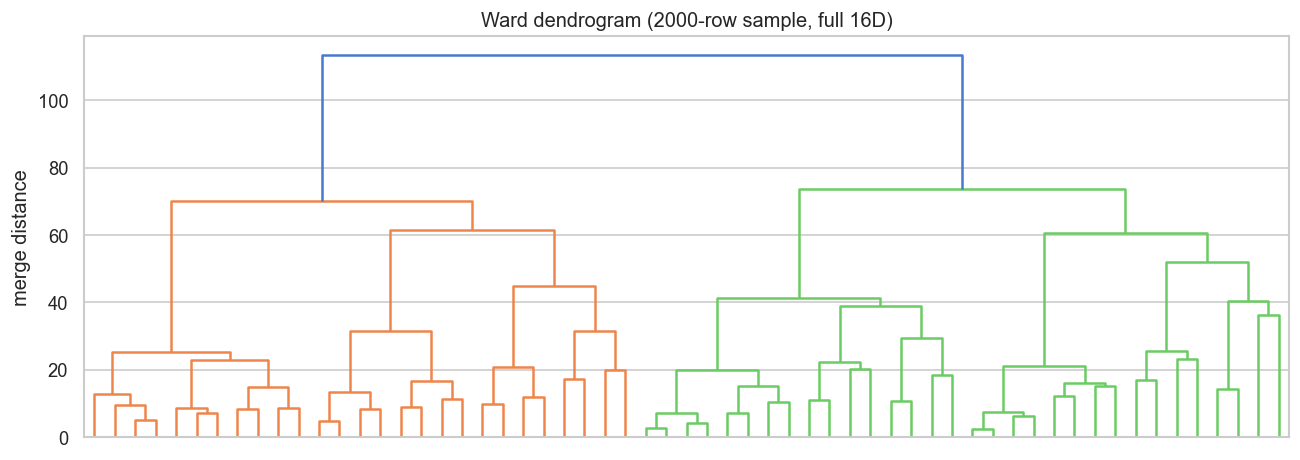

In [8]:
# Ward dendrogram on a small sample: visualize the hierarchical structure.
di = rng.choice(len(X_full), 2000, replace=False)
Z = linkage(X_full[di], method="ward")
fig, ax = plt.subplots(figsize=(11, 4))
dendrogram(Z, truncate_mode="level", p=5, no_labels=True, ax=ax,
           color_threshold=0.7 * max(Z[:, 2]))
ax.set(title="Ward dendrogram (2000-row sample, full 16D)", ylabel="merge distance")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03b_dendrogram.png", bbox_inches="tight")
plt.show()

**Reading the evidence.**

| Criterion | Full 16D | PCA 10D | Bias |
|---|---|---|---|
| Silhouette (max) | **k=2** | **k=2** | favours small k |
| Calinski-Harabasz (max) | **k=2** | **k=2 (~ k=3)** | favours small k |
| Davies-Bouldin (min) | k=15 | k=15 | favours large k |
| Elbow (2nd diff) | **k=3** | **k=3** | - |
| Gap statistic (Tibshirani) | **k=1** | - | weak structure |
| GMM BIC / AIC (min) | k=15 | k=15 | favours large k |
| Stability ARI | k=2 & k=3 = 1.00 | - | k=2, k=3 perfectly stable |
| Dendrogram | one dominant 2-way split | - | then a continuum |

Two facts emerge:

1. **k=2 is the strongest, most stable single split** - silhouette, CH and a perfect
   ARI all agree, in *both* spaces. It is **not** a silhouette artifact, and **PCA does
   not change the ranking**. The dendrogram shows one dominant top-level split (a large
   jump in merge distance), confirming the residential / non-residential divide.
2. **There is no clean "natural" number of clusters.** The gap statistic prefers k=1
   (no compelling structure beyond the uniform null), while GMM BIC keeps decreasing
   toward the largest k tested. Together they say PLUTO is essentially a **continuum**
   driven by a dominant gradient, not a set of well-separated islands.

The honest takeaway so far: k=2 is the best *discrete separation*, but it is the
dominant cut of a continuum rather than "the" true number. The elbow and stability both
flag **k=3** as the principled finer alternative.

## 3. "But the 2D PCA plot looks like 3 clusters"

A natural objection when looking at the PCA projection: the cloud *looks* like three
groups, not two. This is worth taking seriously. Below we (a) show the raw 2D density
with no labels at all, (b) cluster in PCA-10D for k=2..6 and display each result in the
PC1-PC2 plane, and (c) describe exactly what k=3 separates.

In [9]:
LANDUSE_NAMES = {
    1: "1 One/Two-Family", 2: "2 MF Walk-Up", 3: "3 MF Elevator", 4: "4 Mixed Res/Comm",
    5: "5 Commercial", 6: "6 Industrial", 7: "7 Transport", 8: "8 Public",
    9: "9 Open Space", 10: "10 Parking", 11: "11 Vacant",
}

print(f"K-Means in PCA-{K90}D, k = 2..6:")
labels6 = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(Xp)
    labels6[k] = km.labels_
    print(f"  k={k}: silhouette={silhouette_score(Xp[sil_sub], km.labels_[sil_sub]):.3f}"
          f"  CH={calinski_harabasz_score(Xp, km.labels_):8.0f}"
          f"  DB={davies_bouldin_score(Xp, km.labels_):.3f}")

print("\nWhat k=3 actually splits into:")
l3 = labels6[3]
for c in np.unique(l3):
    m = l3 == c
    top = pd.Series(lu[m]).map(LANDUSE_NAMES).value_counts(normalize=True).head(2)
    print(f"  cluster {c}: {m.mean()*100:4.1f}%  PC1={P2[m,0].mean():+.2f} PC2={P2[m,1].mean():+.2f}"
          f"  resid_ratio={rr[m].mean():.2f} | "
          + ", ".join(f"{n} {v*100:.0f}%" for n, v in top.items()))

K-Means in PCA-10D, k = 2..6:


  k=2: silhouette=0.469  CH=   13837  DB=1.621


  k=3: silhouette=0.299  CH=   13826  DB=1.501


  k=4: silhouette=0.213  CH=   11702  DB=1.696


  k=5: silhouette=0.222  CH=   10985  DB=1.527


  k=6: silhouette=0.268  CH=   10668  DB=1.311

What k=3 actually splits into:
  cluster 0: 28.9%  PC1=+0.88 PC2=+2.09  resid_ratio=0.95 | 2 MF Walk-Up 58%, 4 Mixed Res/Comm 25%
  cluster 1: 63.7%  PC1=-1.02 PC2=-0.59  resid_ratio=1.00 | 1 One/Two-Family 97%, 2 MF Walk-Up 3%
  cluster 2:  7.5%  PC1=+5.32 PC2=-3.14  resid_ratio=0.03 | 5 Commercial 39%, 8 Public 21%


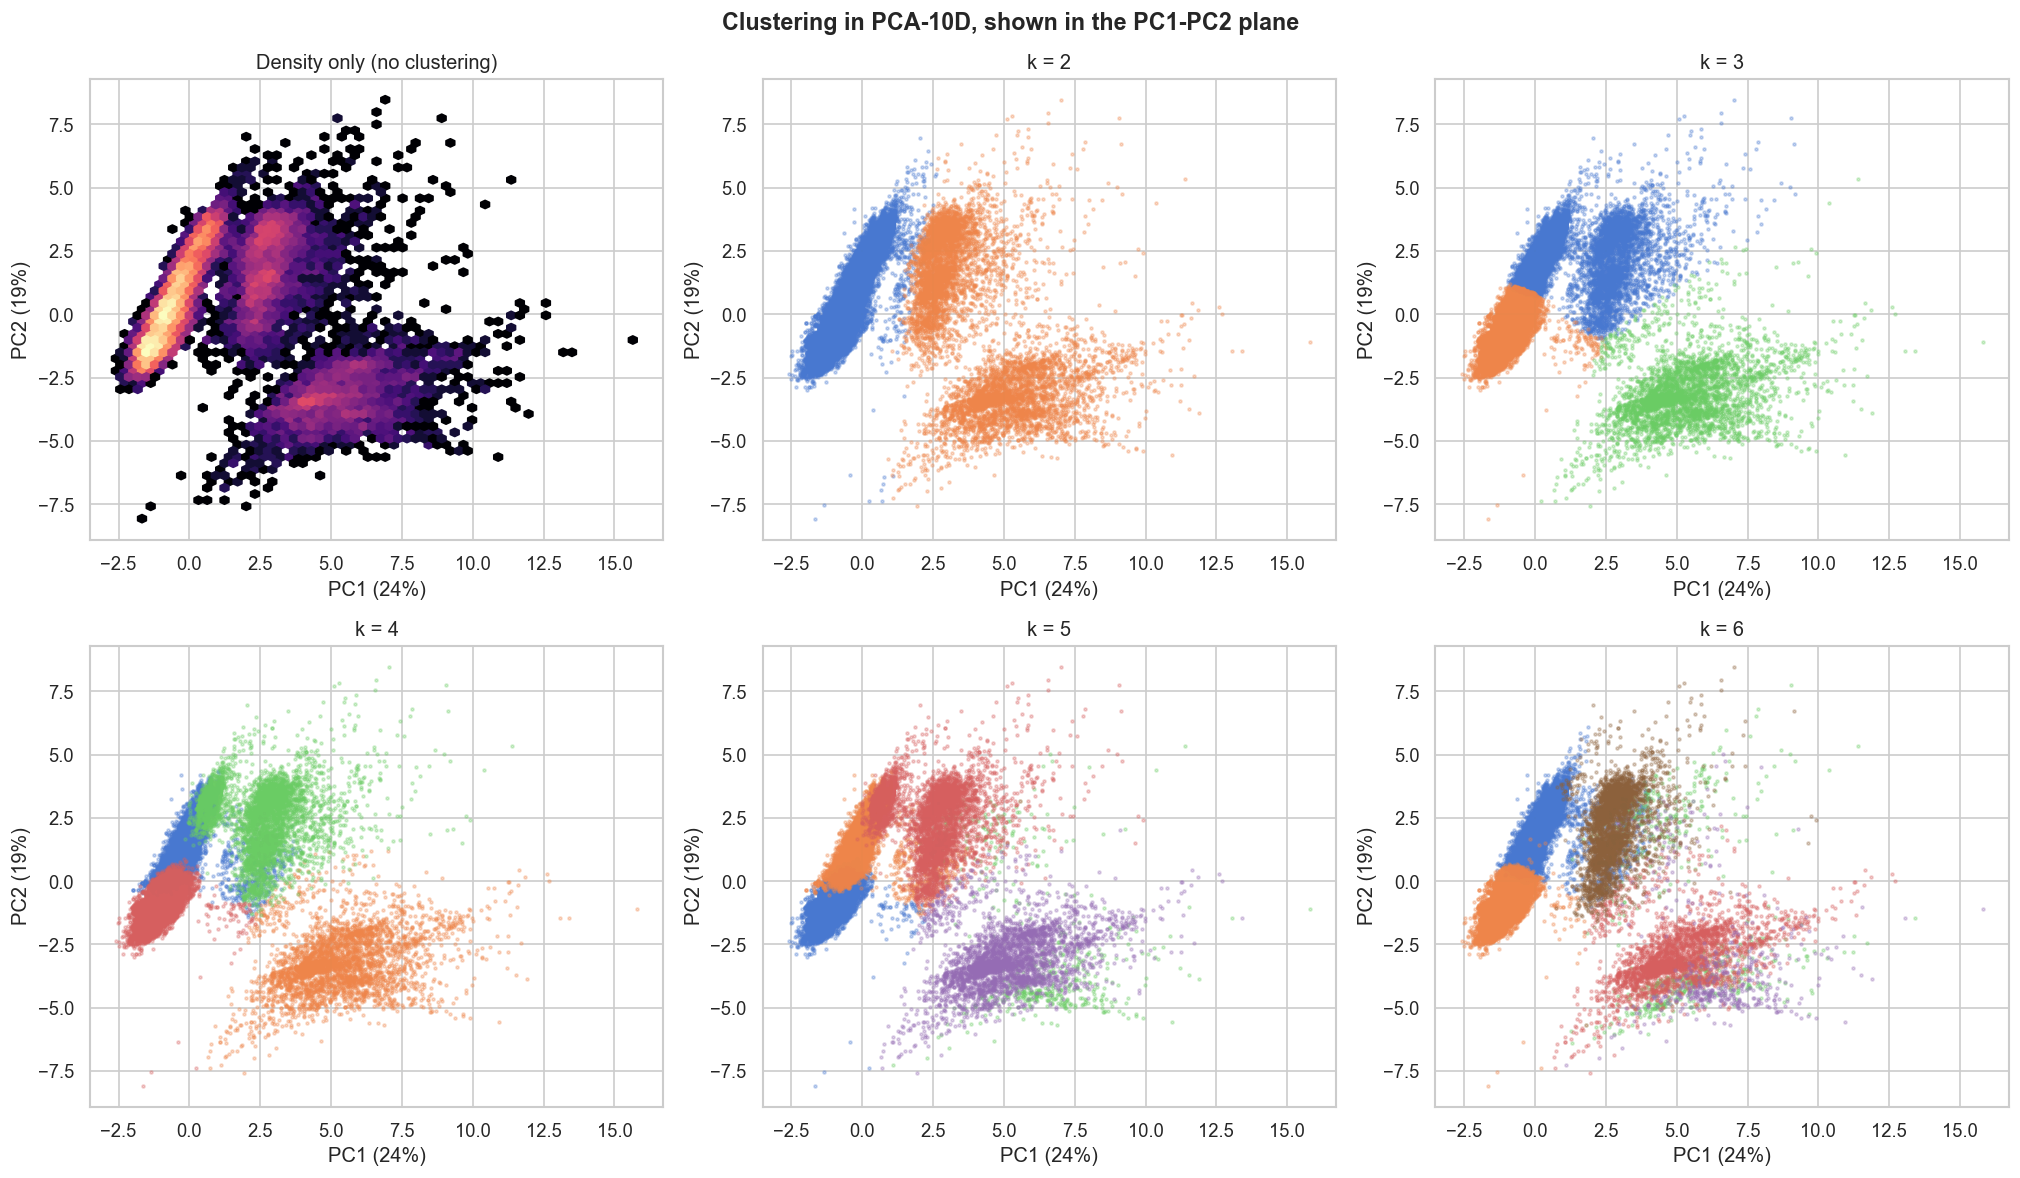

In [10]:
fig, ax = plt.subplots(2, 3, figsize=(17, 10)); ax = ax.ravel()
# panel 0: pure density - how many groups does the eye actually see?
ax[0].hexbin(P2[:, 0], P2[:, 1], gridsize=60, cmap="magma", bins="log")
ax[0].set(title="Density only (no clustering)",
          xlabel=f"PC1 ({evr[0]*100:.0f}%)", ylabel=f"PC2 ({evr[1]*100:.0f}%)")
# panels 1..5: k = 2..6
for i, k in enumerate(range(2, 7), start=1):
    for c in np.unique(labels6[k]):
        m = labels6[k] == c
        ax[i].scatter(P2[m, 0], P2[m, 1], s=3, alpha=0.3)
    ax[i].set(title=f"k = {k}",
              xlabel=f"PC1 ({evr[0]*100:.0f}%)", ylabel=f"PC2 ({evr[1]*100:.0f}%)")
fig.suptitle("Clustering in PCA-10D, shown in the PC1-PC2 plane", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03c_pca_k2_to_k6.png", bbox_inches="tight")
plt.show()

**The "3 clusters" impression is correct - and meaningful.** The density panel shows
three arms, and the k=3 panel cuts exactly along them. The three groups are clean and
interpretable:

| k=3 cluster | Share | `residential_ratio` | Dominant land use | Meaning |
|---|---|---|---|---|
| 0 | ~64% | ~1.00 | ~96% one/two-family | **Single-family houses** |
| 2 | ~28% | ~0.95 | walk-up + mixed | **Dense multi-family residential** |
| 1 | ~8% | ~0.03 | commercial / public | **Non-residential** |

**Why does the silhouette still prefer k=2 then?** k=2 merges *houses + apartments* into a
single "residential" group opposite "non-residential". The third cut (houses vs
apartments) separates **two neighbouring residential groups**, while the
residential vs commercial gap is much wider. The silhouette rewards the **widest gap**,
not the most **informative** partition - so adding a real but tighter split lowers the
average score. Note that on **Calinski-Harabasz**, k=3 essentially ties k=2, and k=3 is
**perfectly stable** (ARI=1.00), so k=3 is not statistically inferior - it simply loses
on the one index that is biased toward the largest separation.

## 4. Verdict

**Is k=2 the best choice, mathematically and statistically?**

- **As the best-separated, most stable single partition: yes.** Silhouette, CH and a
  perfect ARI agree, in full 16D and in PCA space alike. Re-running after PCA
  **confirms** k=2 - it does not overturn it. So k=2 is defensible and not an artifact.
- **As the "true" number of natural groups: no such number exists.** The gap statistic
  (k=1) and GMM BIC (k -> large) show PLUTO is a continuum with one dominant gradient
  (residential vs non-residential), not a set of discrete islands.
- **The 2D plot's "3 groups" are real and more informative.** k=3 cleanly recovers three
  morphologies - houses / dense multi-family / non-residential - ties k=2 on
  Calinski-Harabasz, and is perfectly stable. It loses only on the silhouette, for a
  known structural reason.

**Recommendation.** Report **k=2** as the dominant, fully validated split, but frame it
explicitly as the strongest cut of a continuum (gap statistic), and present **k=3** as
the segmentation used for interpretation: it matches the visual structure, is statistically
on par (CH, stability), and yields three clean, interpretable building typologies. This
directly answers the concern that "k=2 looks suspicious": k=2 is correct but coarse, and
k=3 is the principled, more descriptive refinement.